In [23]:
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [9]:
df = pd.read_csv("insurance.csv")

X = df.drop(columns=["charges"])
Y = df["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype="int")

X['sex'] = X['sex'].map({'female':1,'male':0})
X['smoker'] = X['smoker'].map({'yes':1,"no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
    
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("mse:", mse)

mse: 20918648.8898256


In [12]:
# for multiple alphas
alphas = [0.01, 0.1, 1, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    
    print(f"mse of alpha {a}:", mse)

mse of alpha 0.01: 20922527.32662989
mse of alpha 0.1: 20921803.698431376
mse of alpha 1: 20914832.63508914
mse of alpha 5: 20890881.000633497
mse of alpha 10: 20872844.794796687
mse of alpha 20: 20877828.53237883
mse of alpha 30: 20937537.133939777
mse of alpha 40: 21046489.293890778
mse of alpha 50: 21196929.86960891
mse of alpha 100: 22423172.686023243


<Axes: >

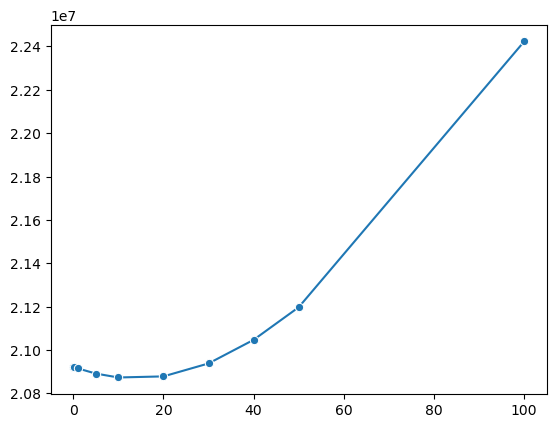

In [15]:
import seaborn as sns

sns.lineplot(x=alphas, y=mses, marker='o')

In [20]:
from sklearn.linear_model import LassoCV
a = [0.01, 0.1, 1, 5, 10, 20, 30, 40, 50, 100]
lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)
print("alpha val:",lasso_cv_model.alpha_)

alpha val: 0.01


In [21]:
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("mse:",mse)

mse: 20922527.32662989


In [24]:
r2 = r2_score(y_test, y_pred)
print("r2 score:",r2)

r2 score: 0.8652322171937452
